# Utvidelse 01 — Timeprofiler for last, vind og sol

Hovednotebooken antar et **konstant** residual effektmangel gjennom hele hendelsen. Det er pedagogisk nyttig, men virkeligheten har timeprofiler:

- **Last** har dag/natt-variasjon og hverdag/helg-variasjon.
- **Sol** er null om natten, ujevn om vinteren.
- **Vind** kan være lav i flere døgn under en Dunkelflaute, men sjelden eksakt null hele tiden.

Denne notebooken bygger en enkel timesoppløst representasjon for å vise hvordan **residualbehovet svinger time for time**, og hvordan det kan gjøre kravet til batteripark både større (peak) og mindre (gjennomsnitt) enn flat-antakelsen.

> Profilene under er **syntetiske** for å illustrere mekanismen. Reell analyse bør bruke ENTSO-E Transparency Platform, MERRA-2 / ERA5 reanalyse eller renewables.ninja.


## Oslo-år som felles målestokk

I alle utvidelsene bruker vi samme norske normalisering: **Oslo ≈ 1 GW kontinuerlig ≈ 8,76 TWh per år**. Det gjør GW- og TWh-tall lettere å lese uten å blande effekt med energi.


In [ ]:
HOURS_PER_YEAR = 8760

anchors = {
    "Norsk husholdning": {"energy_kwh_per_year": 14_700, "source": "SSB 2024"},
    "Bergen kommune": {"energy_twh_per_year": 3.4898, "source": "SSB tabell 14490, 2024"},
    "Oslo kommune": {"energy_twh_per_year": 8.7589, "source": "SSB tabell 14490, 2024"},
    "Statkraft Norge": {"energy_twh_per_year": 51.2, "source": "Statkraft 2025"},
    "Norge forbruk inkl. tap": {"energy_twh_per_year": 139.2, "source": "Statnett 2025"},
    "Norge produksjon": {"energy_twh_per_year": 162.0, "source": "Statnett 2025"},
}


def twh_to_average_gw(twh_per_year):
    return twh_per_year / (HOURS_PER_YEAR / 1000)


def gw_to_twh_per_year(gw):
    return gw * HOURS_PER_YEAR / 1000


def twh_to_oslo_years(twh):
    return twh / anchors["Oslo kommune"]["energy_twh_per_year"]


def oslo_average_gw():
    return twh_to_average_gw(anchors["Oslo kommune"]["energy_twh_per_year"])


def describe_energy(twh):
    return {
        "TWh": twh,
        "Oslo-år": twh_to_oslo_years(twh),
        "Bergen-år": twh / anchors["Bergen kommune"]["energy_twh_per_year"],
        "Statkraft Norge-år": twh / anchors["Statkraft Norge"]["energy_twh_per_year"],
        "Norge-forbruksår": twh / anchors["Norge forbruk inkl. tap"]["energy_twh_per_year"],
        "Gjennomsnittlig GW i ett år": twh_to_average_gw(twh),
    }


In [1]:
from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
candidates = [HERE / "data" / "defaults.json", HERE.parent.parent / "data" / "defaults.json", HERE.parent / "data" / "defaults.json"]
defaults_path = next(p for p in candidates if p.exists())
defaults = json.loads(defaults_path.read_text())["defaults"]
average_load_gw = defaults["average_load_gw"]
event_days = int(defaults["event_days"])
hours = event_days * 24
average_load_gw, event_days, hours


(318.0, 10, 240)

## Syntetiske profiler

Vi konstruerer tre normaliserte profiler over `event_days × 24` timer:

- **Last**: sinusvariasjon rundt døgnsnittet med dagtopp ca. kl 18 og minimum tidlig morgen.
- **Sol**: avkortet sinus mellom soloppgang og solnedgang, med kraftig dempning som under en typisk Dunkelflaute.
- **Vind**: lav, langsomt varierende profil med små topper, igjen kraftig dempet.


In [2]:
rng = np.random.default_rng(42)
t = np.arange(hours)
hour_of_day = t % 24

# Lastprofil: dagsnitt = average_load_gw, ±20 % døgnvariasjon
load_gw = average_load_gw * (1 + 0.20 * np.sin(2 * np.pi * (hour_of_day - 14) / 24))

# Solprofil under Dunkelflaute: maks ca 15 GW (mot ca 200+ GW potensial i sommerdøgn)
solar_clear = np.clip(np.sin(np.pi * (hour_of_day - 6) / 12), 0, None)
solar_gw = 15 * solar_clear * (0.4 + 0.2 * rng.random(hours))

# Vindprofil under Dunkelflaute: trend rundt 20 GW (mot 150+ GW i normalvær)
slow = np.cumsum(rng.normal(0, 1, hours))
slow = (slow - slow.min()) / (slow.max() - slow.min() + 1e-9)
wind_gw = 10 + 20 * slow

profiles = pd.DataFrame({
    "time_h": t,
    "last_GW": load_gw,
    "sol_GW": solar_gw,
    "vind_GW": wind_gw,
})
profiles.head()


,time_h,last_GW,sol_GW,vind_GW
0,0,349.800000,0.0,19.146953
1,1,334.460891,0.0,18.482628
2,2,318.000000,0.0,16.301929
3,3,301.539109,0.0,16.136732
4,4,286.200000,0.0,15.057787


## Residualbehov

Definer residualbehov som **last − sol − vind − annen fast produksjon**. For å sammenligne med hovednotebooken bruker vi en fast «alt annet» (kjernekraft, vannkraft, import, termisk) på `firm_other_gw`.


In [3]:
firm_other_gw = 60.0  # pedagogisk antakelse, ikke kildeverdi

profiles["residual_GW"] = (
    profiles["last_GW"] - profiles["sol_GW"] - profiles["vind_GW"] - firm_other_gw
).clip(lower=0)

flat_estimate_gw = defaults["residual_gap_gw"]
print(f"Flat antakelse i hovednotebook: {flat_estimate_gw:.0f} GW konstant")
print(f"Profilbasert snitt:             {profiles['residual_GW'].mean():.1f} GW")
print(f"Profilbasert peak:              {profiles['residual_GW'].max():.1f} GW")
print(f"Profilbasert min:               {profiles['residual_GW'].min():.1f} GW")
print(f"Profilbasert snitt tilsvarer:   {profiles['residual_GW'].mean()/oslo_average_gw():.1f} Oslo i snitteffekt")


Flat antakelse i hovednotebook: 250 GW konstant
Profilbasert snitt:             236.3 GW
Profilbasert peak:              307.5 GW
Profilbasert min:               165.5 GW


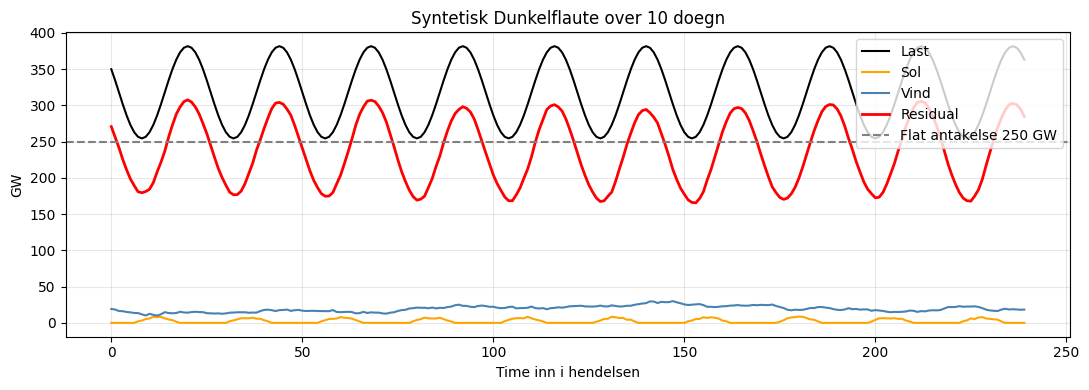

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(profiles["time_h"], profiles["last_GW"], label="Last", color="black")
ax.plot(profiles["time_h"], profiles["sol_GW"], label="Sol", color="orange")
ax.plot(profiles["time_h"], profiles["vind_GW"], label="Vind", color="steelblue")
ax.plot(profiles["time_h"], profiles["residual_GW"], label="Residual", color="red", linewidth=2)
ax.axhline(flat_estimate_gw, linestyle="--", color="grey", label=f"Flat antakelse {flat_estimate_gw:.0f} GW")
ax.set_xlabel("Time inn i hendelsen")
ax.set_ylabel("GW")
ax.set_title(f"Syntetisk Dunkelflaute over {event_days} døgn")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Energibehov fra timeprofil vs. flat antakelse


In [5]:
delivered_twh_profile = profiles["residual_GW"].sum() / 1000  # GWh -> TWh
delivered_twh_flat = flat_estimate_gw * hours / 1000

print(f"Levert energi (profil): {delivered_twh_profile:.2f} TWh")
print(f"Levert energi (flat):   {delivered_twh_flat:.2f} TWh")
print(f"Oslo-år (profil):       {twh_to_oslo_years(delivered_twh_profile):.2f}")
print(f"Oslo-år (flat):         {twh_to_oslo_years(delivered_twh_flat):.2f}")
print(f"Forhold:                {delivered_twh_profile/delivered_twh_flat:.2f}")


Levert energi (profil): 56.72 TWh
Levert energi (flat):   60.00 TWh
Forhold:                0.95


## Læring

- Et timeprofil gir **både lavere snitt og høyere peak** enn flat-antakelsen — det første reduserer energibehov, det andre øker effektkrav.
- Hovednotebookens flate `P × 24 × d` er en **konservativ energiantakelse** dersom profilene blir liggende lavt, men kan **undervurdere effektkravet** i enkelttimer.
- Neste utvidelse skiller derfor effektkapasitet (GW) fra energikapasitet (GWh/TWh).
